In [1]:
import os
import torch
from torch import nn, optim
from torch.utils.data import DataLoader, Subset, WeightedRandomSampler
from torchvision import datasets, models, transforms
from collections import Counter
import numpy as np
import time, copy


In [23]:
# Ruta del dataset TACO
data_dir = r"C:\Users\soria\Downloads\Metodología\Clasificacion_residuos\data_preprocessed\ResNet18\TACO"

# Transformación vacía (solo convierte a tensor, sin alterar tamaño ni color)
no_transform = transforms.Compose([transforms.ToTensor()])

# Cargar dataset completo
full_taco = datasets.ImageFolder(data_dir, transform=no_transform)

print(f"Total de imágenes en TACO: {len(full_taco)}")
print(f"Clases detectadas: {full_taco.classes}")


Total de imágenes en TACO: 4374
Clases detectadas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [25]:
def split_stratified(dataset, train_ratio=0.7, val_ratio=0.15, seed=42):
    np.random.seed(seed)
    targets = np.array(dataset.targets)
    classes = np.unique(targets)
    
    train_idx, val_idx, test_idx = [], [], []
    for c in classes:
        c_idx = np.where(targets == c)[0]
        np.random.shuffle(c_idx)
        n_total = len(c_idx)
        n_train = int(train_ratio * n_total)
        n_val = int(val_ratio * n_total)
        n_test = n_total - n_train - n_val
        train_idx += list(c_idx[:n_train])
        val_idx   += list(c_idx[n_train:n_train+n_val])
        test_idx  += list(c_idx[n_train+n_val:])
    
    return train_idx, val_idx, test_idx

train_idx, val_idx, test_idx = split_stratified(full_taco)
train_ds = Subset(full_taco, train_idx)
val_ds   = Subset(full_taco, val_idx)
test_ds  = Subset(full_taco, test_idx)

print("Tamaños -> Train:", len(train_ds), "Val:", len(val_ds), "Test:", len(test_ds))


Tamaños -> Train: 3058 Val: 653 Test: 663


In [27]:
def make_balanced_sampler(subset, full_dataset):
    targets = np.array(full_dataset.targets)
    subset_targets = targets[subset.indices]
    class_counts = Counter(subset_targets)
    weights = {cls: 1.0/count for cls, count in class_counts.items()}
    sample_weights = [weights[label] for label in subset_targets]
    return WeightedRandomSampler(sample_weights, num_samples=len(sample_weights), replacement=True)

train_sampler = make_balanced_sampler(train_ds, full_taco)


In [29]:
batch_size = 32
train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=train_sampler, num_workers=2)
val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False, num_workers=2)

dataloaders = {"train": train_loader, "val": val_loader}
dataset_sizes = {"train": len(train_ds), "val": len(val_ds)}
class_names = full_taco.classes


In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def build_resnet18_dropout(num_classes):
    model = models.resnet18(weights="IMAGENET1K_V1")
    for p in model.parameters():
        p.requires_grad = False  # congelar capas convolucionales

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )
    return model.to(device)

model = build_resnet18_dropout(len(class_names))
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)


In [33]:
# Configurar carpeta de salida
output_dir = r"C:\Users\soria\Downloads\Modelos_Experimentos"
os.makedirs(output_dir, exist_ok=True)

# Función de entrenamiento con guardado
def train_model(model, criterion, optimizer, dataloaders, dataset_sizes,
                num_epochs=20, patience=4, save_name="resnet18_taco_v2.pth"):
    """
    Entrena una red neuronal ResNet-18 con early stopping
    y guarda el mejor modelo en una carpeta fuera del repositorio.
    """
    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 40)

        for phase in ["train", "val"]:
            if phase == "train":
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == "train"):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == "train":
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f"{phase.upper():5} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            # Guardar el mejor modelo
            if phase == "val":
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        # Early stopping si no mejora por varias épocas
        if epochs_no_improve >= patience:
            print(f"\n  Early stopping en la época {epoch+1}")
            break

    # Cargar el mejor modelo y guardar
    model.load_state_dict(best_wts)
    save_path = os.path.join(output_dir, save_name)
    torch.save(model.state_dict(), save_path)

    time_elapsed = time.time() - since
    print(f"\nEntrenamiento completo en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Mejor ACC en validación: {best_acc:.4f}")
    print(f"Modelo guardado en: {save_path}")

    return model


In [35]:
# Configurar el dispositivo (CPU o GPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Función para construir ResNet-18 con Dropout
def build_resnet18_dropout(num_classes):
    """
    Crea una red ResNet-18 preentrenada con las capas convolucionales congeladas
    y una nueva capa final con dropout para reducir sobreajuste.
    """
    model = models.resnet18(weights="IMAGENET1K_V1")

    # Congelamos las capas convolucionales (fase 1)
    for param in model.parameters():
        param.requires_grad = False

    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Dropout(p=0.5),
        nn.Linear(in_features, num_classes)
    )
    return model.to(device)

# Inicialización del modelo
model = build_resnet18_dropout(len(class_names))

# Definir función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)


In [37]:
modelo_taco_v2 = train_model(
    model,
    criterion,
    optimizer,
    dataloaders,
    dataset_sizes,
    num_epochs=10,       # máximo de épocas
    patience=5,          # early stopping
    save_name="resnet18_taco_balanceado_v2.pth"
)



Época 1/10
----------------------------------------
TRAIN | Loss: 1.7244 | Acc: 0.2956
VAL   | Loss: 1.5207 | Acc: 0.4074

Época 2/10
----------------------------------------
TRAIN | Loss: 1.4068 | Acc: 0.4470
VAL   | Loss: 1.4706 | Acc: 0.4119

Época 3/10
----------------------------------------
TRAIN | Loss: 1.3307 | Acc: 0.4804
VAL   | Loss: 1.4312 | Acc: 0.4273

Época 4/10
----------------------------------------
TRAIN | Loss: 1.2425 | Acc: 0.5304
VAL   | Loss: 1.5226 | Acc: 0.3997

Época 5/10
----------------------------------------
TRAIN | Loss: 1.2730 | Acc: 0.5128
VAL   | Loss: 1.2939 | Acc: 0.5253

Época 6/10
----------------------------------------
TRAIN | Loss: 1.2320 | Acc: 0.5386
VAL   | Loss: 1.2788 | Acc: 0.4992

Época 7/10
----------------------------------------
TRAIN | Loss: 1.1917 | Acc: 0.5602
VAL   | Loss: 1.2213 | Acc: 0.5681

Época 8/10
----------------------------------------
TRAIN | Loss: 1.2138 | Acc: 0.5494
VAL   | Loss: 1.3130 | Acc: 0.5115

Época 9/10
----

In [39]:
# Fase 2: Fine-tuning
for param in model.parameters():
    param.requires_grad = True  # Descongelar todas las capas

optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Entrenamiento completo (todas las capas)
modelo_taco_v2_finetuned = train_model(
    model,
    criterion,
    optimizer,
    dataloaders,
    dataset_sizes,
    num_epochs=10,
    patience=3,
    save_name="resnet18_taco_balanceado_v2_finetuned.pth"
)



Época 1/10
----------------------------------------
TRAIN | Loss: 0.7803 | Acc: 0.7217
VAL   | Loss: 1.1057 | Acc: 0.6080

Época 2/10
----------------------------------------
TRAIN | Loss: 0.3670 | Acc: 0.8842
VAL   | Loss: 0.9725 | Acc: 0.6708

Época 3/10
----------------------------------------
TRAIN | Loss: 0.2325 | Acc: 0.9274
VAL   | Loss: 0.9285 | Acc: 0.6861

Época 4/10
----------------------------------------
TRAIN | Loss: 0.1510 | Acc: 0.9532
VAL   | Loss: 0.9151 | Acc: 0.6922

Época 5/10
----------------------------------------
TRAIN | Loss: 0.1045 | Acc: 0.9683
VAL   | Loss: 0.9641 | Acc: 0.6922

Época 6/10
----------------------------------------
TRAIN | Loss: 0.0739 | Acc: 0.9787
VAL   | Loss: 1.0803 | Acc: 0.6891

Época 7/10
----------------------------------------
TRAIN | Loss: 0.0574 | Acc: 0.9853
VAL   | Loss: 1.0411 | Acc: 0.6830

  Early stopping en la época 7

Entrenamiento completo en 34m 15s
Mejor ACC en validación: 0.6922
Modelo guardado en: C:\Users\soria\Downl


=== Reporte de Clasificación ===
              precision    recall  f1-score   support

   cardboard       0.65      0.56      0.60        36
       glass       0.70      0.50      0.58        38
       metal       0.62      0.77      0.69        79
       paper       0.63      0.50      0.56        34
     plastic       0.71      0.76      0.73       287
       trash       0.78      0.69      0.73       189

    accuracy                           0.70       663
   macro avg       0.68      0.63      0.65       663
weighted avg       0.71      0.70      0.70       663



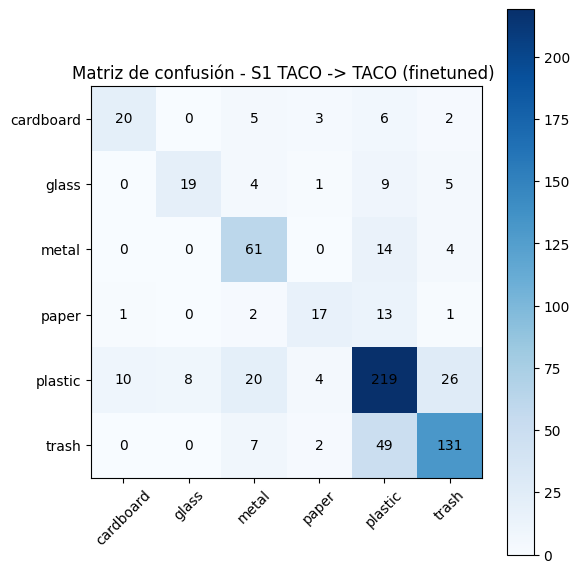

In [43]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

def evaluar_en_test(model, loader, class_names):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds += preds.cpu().numpy().tolist()
            all_labels += labels.cpu().numpy().tolist()

    print("\n=== Reporte de Clasificación ===")
    print(classification_report(all_labels, all_preds, target_names=class_names))

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,6))
    plt.imshow(cm, cmap="Blues")
    plt.title("Matriz de confusión - S1 TACO -> TACO (finetuned) ")
    plt.xticks(range(len(class_names)), class_names, rotation=45)
    plt.yticks(range(len(class_names)), class_names)
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i,j], ha="center", va="center")
    plt.colorbar()
    plt.tight_layout()
    plt.show()

evaluar_en_test(modelo_taco_v2_finetuned, test_loader, class_names)


Total imágenes: 4374
Entrenamiento: 3061, Validación: 656, Test: 657
Clases detectadas: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


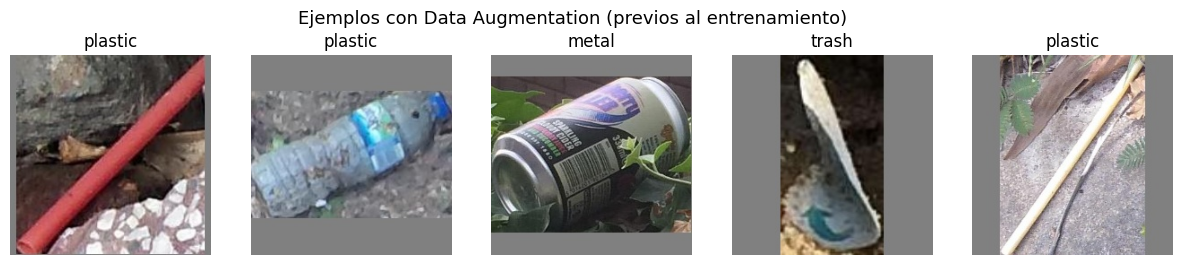


 FASE 1: Entrenamiento de la capa final (capas congeladas)

Época 1/10
----------------------------------------
TRAIN | Loss: 1.3439 | Acc: 0.5162
VAL   | Loss: 1.1143 | Acc: 0.6189

Época 2/10
----------------------------------------
TRAIN | Loss: 1.0961 | Acc: 0.6132
VAL   | Loss: 1.0399 | Acc: 0.6433

Época 3/10
----------------------------------------
TRAIN | Loss: 1.0103 | Acc: 0.6364
VAL   | Loss: 0.9804 | Acc: 0.6570

Época 4/10
----------------------------------------
TRAIN | Loss: 0.9677 | Acc: 0.6615
VAL   | Loss: 0.9619 | Acc: 0.6570

Época 5/10
----------------------------------------
TRAIN | Loss: 0.9363 | Acc: 0.6596
VAL   | Loss: 0.9280 | Acc: 0.6768

Época 6/10
----------------------------------------
TRAIN | Loss: 0.9106 | Acc: 0.6762
VAL   | Loss: 0.9324 | Acc: 0.6555

Época 7/10
----------------------------------------
TRAIN | Loss: 0.9030 | Acc: 0.6762
VAL   | Loss: 0.9176 | Acc: 0.6784

Época 8/10
----------------------------------------
TRAIN | Loss: 0.8799 | Acc

In [62]:
# BLOQUE: Entrenamiento con Data Augmentation

import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
import os, copy, time
import matplotlib.pyplot as plt
import numpy as np

# Ruta al dataset preprocesado (ya redimensionado)
data_dir = r"C:\Users\soria\Downloads\Metodología\Clasificacion_residuos\data_preprocessed\ResNet18\TACO"

# Data Augmentation para entrenamiento
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.3),       # voltear horizontalmente
    transforms.RandomRotation(5),                # rotar máximo ±10 grados
    transforms.ColorJitter(brightness=0.1, contrast=0.1),  # ligeros cambios de luz
    transforms.ToTensor()
])

# Transformación básica para validación y test
base_transform = transforms.Compose([
    transforms.ToTensor()
])

# Carga del dataset completo con el transform de entrenamiento
full_dataset = datasets.ImageFolder(data_dir, transform=train_transform)
total = len(full_dataset)

# División 70-15-15
torch.manual_seed(42)
train_size = int(0.7 * total)
val_size = int(0.15 * total)
test_size = total - train_size - val_size
train_ds, val_ds, test_ds = random_split(full_dataset, [train_size, val_size, test_size])

# A val y test les asignamos la transformación sin augmentación
val_ds.dataset.transform = base_transform
test_ds.dataset.transform = base_transform

# Dataloaders
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True, num_workers=2)
val_loader = DataLoader(val_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

dataloaders = {'train': train_loader, 'val': val_loader}
dataset_sizes = {'train': len(train_ds), 'val': len(val_ds)}

class_names = full_dataset.classes
print(f"Total imágenes: {total}")
print(f"Entrenamiento: {len(train_ds)}, Validación: {len(val_ds)}, Test: {len(test_ds)}")
print(f"Clases detectadas: {class_names}")

# VISUALIZACIÓN DE AUGMENTATION ANTES DEL ENTRENAMIENTO

def mostrar_augmentacion(dataset, class_names, n=5):
    
    #Muestra n imágenes del dataset con augmentación aplicada.
    fig, axes = plt.subplots(1, n, figsize=(15, 3))
    for i in range(n):
        img, label = dataset[i]
        img = img.permute(1, 2, 0).numpy()  # cambiar a HWC para matplotlib
        img = np.clip(img, 0, 1)            # asegurar rango [0,1]
        axes[i].imshow(img)
        axes[i].set_title(class_names[label])
        axes[i].axis("off")
    plt.suptitle("Ejemplos con Data Augmentation (previos al entrenamiento)", fontsize=13)
    plt.show()

# Mostrar 5 ejemplos del dataset de entrenamiento
mostrar_augmentacion(train_ds, class_names, n=5)


# DEFINICIÓN DEL MODELO Y ENTRENAMIENTO

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar ResNet18 preentrenada
model = models.resnet18(weights="IMAGENET1K_V1")

# Congelar capas convolucionales
for param in model.parameters():
    param.requires_grad = False

# Reemplazar la capa final según el número de clases
num_ftrs = model.fc.in_features
model.fc = nn.Linear(num_ftrs, len(class_names))
model = model.to(device)

# Pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

# Carpeta de salida para modelos
output_dir = r"C:\Users\soria\Downloads\Modelos_Experimentos"
os.makedirs(output_dir, exist_ok=True)

# === Función de entrenamiento con Early Stopping ===
def train_model(model, criterion, optimizer, dataloaders, dataset_sizes,
                num_epochs=10, patience=5, save_name="resnet18_taco_aug_v2.pth"):
    since = time.time()
    best_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        print(f"\nÉpoca {epoch+1}/{num_epochs}")
        print("-" * 40)

        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()

            running_loss = 0.0
            running_corrects = 0

            for inputs, labels in dataloaders[phase]:
                inputs, labels = inputs.to(device), labels.to(device)
                optimizer.zero_grad()

                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)

                    if phase == 'train':
                        loss.backward()
                        optimizer.step()

                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels)

            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            print(f"{phase.upper():5} | Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}")

            if phase == 'val':
                if epoch_acc > best_acc:
                    best_acc = epoch_acc
                    best_wts = copy.deepcopy(model.state_dict())
                    epochs_no_improve = 0
                else:
                    epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"\n Early stopping en época {epoch+1}")
            break

    model.load_state_dict(best_wts)
    save_path = os.path.join(output_dir, save_name)
    torch.save(model.state_dict(), save_path)

    time_elapsed = time.time() - since
    print(f"\nEntrenamiento completo en {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s")
    print(f"Mejor ACC de validación: {best_acc:.4f}")
    print(f"Modelo guardado en: {save_path}")
    return model


# EJECUCIÓN DEL ENTRENAMIENTO

# FASE 1: Entrenamiento solo de la capa final
print("\n FASE 1: Entrenamiento de la capa final (capas congeladas)")
modelo_taco_aug = train_model(
    model, criterion, optimizer, dataloaders, dataset_sizes,
    num_epochs=10, patience=5,
    save_name="resnet18_taco_aug_fase1.pth"
)

# FASE 2: Fine-Tuning
print("\n FASE 2: Fine-Tuning (descongelar todas las capas)")
for param in model.parameters():
    param.requires_grad = True  # descongelar todas las capas

# Reducir la tasa de aprendizaje para evitar sobreajuste
optimizer = optim.Adam(model.parameters(), lr=1e-4)

modelo_taco_finetuned = train_model(
    model, criterion, optimizer, dataloaders, dataset_sizes,
    num_epochs=10, patience=5,
    save_name="resnet18_taco_aug_finetuned.pth"
)




 Evaluando modelo Fase 2 (fine-tuning completo)...

=== Reporte de Clasificación - TACO Fine-Tuning ===
              precision    recall  f1-score   support

   cardboard      0.548     0.515     0.531        33
       glass      0.818     0.450     0.581        40
       metal      0.765     0.732     0.748        71
       paper      0.417     0.227     0.294        22
     plastic      0.746     0.863     0.800       306
       trash      0.800     0.735     0.766       185

    accuracy                          0.749       657
   macro avg      0.682     0.587     0.620       657
weighted avg      0.747     0.749     0.741       657



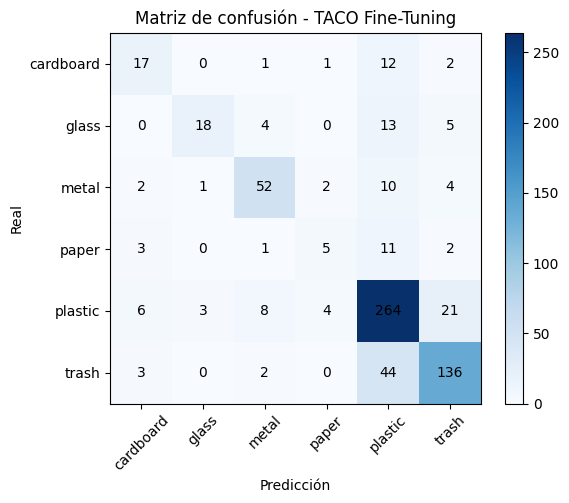

Exactitud global en TEST (TACO Fine-Tuning): 0.7489


In [68]:
# BLOQUE: Evaluación del modelo entrenado en el conjunto TEST

from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Función para evaluar
def evaluar_en_test(model, loader, class_names, modelo_nombre="ResNet18 TACO"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # Reporte de métricas
    print(f"\n=== Reporte de Clasificación - {modelo_nombre} ===")
    print(classification_report(all_labels, all_preds, target_names=class_names, digits=3))

    # Matriz de confusión
    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(6,5))
    plt.imshow(cm, cmap='Blues')
    plt.title(f"Matriz de confusión - {modelo_nombre}")
    plt.xlabel("Predicción")
    plt.ylabel("Real")
    plt.xticks(np.arange(len(class_names)), class_names, rotation=45)
    plt.yticks(np.arange(len(class_names)), class_names)
    
    # Etiquetas numéricas dentro de cada celda
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            plt.text(j, i, cm[i, j], ha="center", va="center", color="black")
    
    plt.colorbar()
    plt.tight_layout()
    plt.show()

    # Exactitud global
    acc = np.mean(np.array(all_preds) == np.array(all_labels))
    print(f"Exactitud global en TEST ({modelo_nombre}): {acc:.4f}")

    return acc

print("\n Evaluando modelo Fase 2 (fine-tuning completo)...")
acc_ft = evaluar_en_test(modelo_taco_finetuned, test_loader, class_names, modelo_nombre="TACO Fine-Tuning")
